<a href="https://colab.research.google.com/github/romancgilbert/ML-Assignment-03/blob/main/03_assignment_linear_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is linear if it is linear in parameters aka the coefficients, not necessarily the features. Linear models have parameters which are multiplied by inputs. This means the predicted output is a weighted sum of the inputs: y^=β0+β1x1+β2x2+…

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

When a categorical variable is one-hot-encoded this means that one category is going to be omitted and becomes the reference variable (is the intercept) and then the dummy variable's coefficient describes how the reference variable is  changed to equate to the dummy variable. In other words, the intercept gives the predicted value for the reference group, and the dummy variable’s coefficient shows how much higher or lower the predicted value is for that category relative to the reference.

3. Can linear regression be used for classification? Explain why, or why not.

Linear-regression can technically be used for classification because we could say if y^ is less than or equal to "x" then it should be classified as a "b" otherwise classify it as a "c". However, it is largely uncommon and not very appropriate to use linear-regression as a form of classification because the predictions  that come from this type of regression are unbounded by 1 or 0, so they could be well over or under 1 and 0. It assumes a linear relationship and constant variance, and it is sensitive to outliers. Classification models such as logistic regression would work much better because it classifies probabilities between 1 and 0, which would be better suited.

4. What are signs that your linear model is over-fitting?

A linear model is most likely over fitting if the model fits the training data too heavily and doesn't leave room for variation among new data. The model learns all the noise/quirks/unique specificities of the training data, which is memorization instead of learning the general patterns.

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multicollinearity is when two or more variables are so intertwined that it causes bias and inaccuracy in your model. For example, when predicting academic performance using study time, higher-IQ students naturally study more, so "hours studied" gets tangled up with "natural ability" and you can't isolate the true effect of studying alone. 2SLS fixes this by first using an instrument like a mandatory study hall policy to extract only the "policy-driven" variation in study hours (Stage 1), then regressing grades on that cleaned-up version of study hours (Stage 2). This strips out the natural ability component and leaves you with an unbiased estimate of how much studying actually matters.

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

Even though a linear model is just a weighted sum, you can still capture nonlinear relationships by transforming your inputs before feeding them in. For example, if the relationship between $x$ and $y$ looks like a curve, you can add $x^2$ or $x^3$ as extra features. If the effect of one variable depends on another, you can multiply them together as an interaction term. And if your data grows exponentially, a log transformation can help straighten that relationship out. The model stays "linear" because the coefficients are still just being multiplied and added up, you are just preparing the inputs differently to better capture the true shape of the relationship.

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient tells you the weighting of how much $y$ is expected to change for a one unit increase in $x$, assuming everything else stays the same. For example, if you are predicting house prices and the bedroom coefficient is $20,000, it means adding one extra bedroom increases the predicted price by $20,000, assuming the size, location, and all other variables stay constant. It is basically just measuring the isolated effect of one variable on the outcome.

8. Compare the train/test split and $k$-fold cross validation.

Train/test split is the simpler approach where you split your data once into two chunks, train the model on one and test it on the other. The problem is that the result depends heavily on how lucky or unlucky you were with that one split. K-fold cross validation is more thorough where you split the data into
k groups and repeat the train/test process
k times, each time using a different group as the test set, then average the results. This gives you a much more reliable and stable estimate of how well your model actually generalizes.

9. How is the $k$ in $k$-fold cross validation typically selected?

The most common choices are 5 or 10, and it comes down to a simple tradeoff. Too small a
k means your training sets are too small and the model doesn't get enough data to learn from, leading to biased results. Too large a
k gets computationally expensive and the results get noisy. Through a lot of experimentation, 5 and 10 have been found to hit the sweet spot between getting reliable estimates and not taking forever to compute.

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error

# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('./scratchpad/data/Q1_clean.csv')
df.rename(columns={' Neighbourhood': 'Neighbourhood',
                   'Neighbourhood ': 'Neighbourhood'}, errors='ignore', inplace=True)
df.columns = df.columns.str.strip()
print(df.head())
print(df.columns.tolist())

   Price  Review Scores Rating Neighbourhood Property Type        Room Type
0    549                  96.0     Manhattan     Apartment     Private room
1    149                 100.0      Brooklyn     Apartment  Entire home/apt
2    250                 100.0     Manhattan     Apartment  Entire home/apt
3     90                  94.0      Brooklyn     Apartment     Private room
4    270                  90.0     Manhattan     Apartment  Entire home/apt
['Price', 'Review Scores Rating', 'Neighbourhood', 'Property Type', 'Room Type']



Average Price and Rating by Neighbourhood:
                Price  Review Scores Rating
Neighbourhood                              
Manhattan      183.66                 91.80
Staten Island  146.17                 90.84
Brooklyn       127.75                 92.36
Queens          96.86                 91.55
Bronx           75.28                 91.65


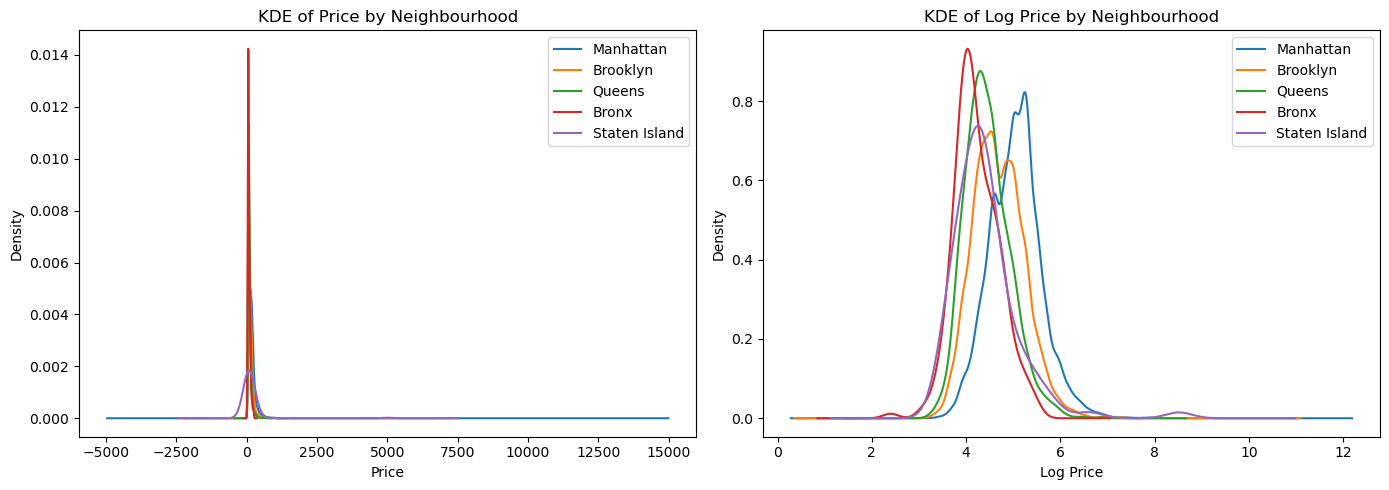

In [ ]:
# ── Q2.1 — Average price & score by neighbourhood + KDE plots ─────────────────
summary = df.groupby('Neighbourhood')[['Price', 'Review Scores Rating']].mean().round(2)
print("\nAverage Price and Rating by Neighbourhood:")
print(summary.sort_values('Price', ascending=False))

df['log_price'] = np.log(df['Price'] + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for neighbourhood in df['Neighbourhood'].unique():
    subset = df[df['Neighbourhood'] == neighbourhood]
    subset['Price'].plot.kde(ax=axes[0], label=neighbourhood)
    subset['log_price'].plot.kde(ax=axes[1], label=neighbourhood)

axes[0].set_title('KDE of Price by Neighbourhood')
axes[0].set_xlabel('Price')
axes[0].legend()

axes[1].set_title('KDE of Log Price by Neighbourhood')
axes[1].set_xlabel('Log Price')
axes[1].legend()

plt.tight_layout()
plt.savefig('kde_plots.png', dpi=150)
plt.show()

In [ ]:
# ── Q2.2 — Regress price on neighbourhood dummies ─────────────────────────────
# Dropping the first category (Bronx as baseline) and keeping the intercept
dummies = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
X2 = sm.add_constant(dummies)
model2 = sm.OLS(df['Price'], X2).fit()
print("\n--- Q2.2: Regression of Price on Neighbourhood Dummies ---")
print(model2.summary())

print("\nComparison: Group Means vs Coefficients")
print("Intercept (baseline group mean):", round(model2.params['const'], 2))
print("Other coefficients = difference from baseline group mean")
print(summary.sort_values('Price'))


--- Q2.2: Regression of Price on Neighbourhood Dummies ---
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        03:33:15   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------

In [ ]:
# ── Q2.3 — Regress price on Review Scores Rating ──────────────────────────────
df_clean = df.dropna(subset=['Price', 'Review Scores Rating'])
X3 = sm.add_constant(df_clean['Review Scores Rating'])
model3 = sm.OLS(df_clean['Price'], X3).fit()
print("\n--- Q2.3: Regression of Price on Review Scores Rating ---")
print(model3.summary())
print(f"\nSlope interpretation: A one-unit increase in Review Scores Rating is associated "
      f"with a ${model3.params['Review Scores Rating']:.2f} change in price, holding all else constant.")


--- Q2.3: Regression of Price on Review Scores Rating ---
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        03:33:15   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

In [ ]:
# ── Q2.4 — Regress price on Neighbourhood + Review Scores Rating ──────────────
dummies4 = pd.get_dummies(df_clean['Neighbourhood'], drop_first=True, dtype=int)
X4 = sm.add_constant(pd.concat([dummies4, df_clean['Review Scores Rating']], axis=1))
model4 = sm.OLS(df_clean['Price'], X4).fit()
X3_reset = sm.add_constant(df_clean['Review Scores Rating']).reset_index(drop=True)
rmse3, std3 = cross_val_rmse(X3_reset, y)

print(f"Model 3 (Rating only):                   RMSE = {rmse3:.2f} (+/- {std3:.2f})")
print(f"Model 4 (Neighbourhood + Rating):        RMSE = {rmse4:.2f} (+/- {std4:.2f})")
print(f"Model 5 (Separate slopes per borough):   RMSE = {rmse5:.2f} (+/- {std5:.2f})")
print("\n--- Q2.4: Regression of Price on Neighbourhood + Review Scores Rating ---")
print(model4.summary())
print(f"\nSlope on Review Scores Rating (Q2.3): {model3.params['Review Scores Rating']:.4f}")
print(f"Slope on Review Scores Rating (Q2.4): {model4.params['Review Scores Rating']:.4f}")

Model 3 (Rating only):                   RMSE = 144.17 (+/- 35.95)
Model 4 (Neighbourhood + Rating):        RMSE = 140.52 (+/- 36.40)
Model 5 (Separate slopes per borough):   RMSE = 140.43 (+/- 36.42)

--- Q2.4: Regression of Price on Neighbourhood + Review Scores Rating ---
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        03:33:15   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Ty

In [ ]:
# ── Q2.5 — Separate slope for each neighbourhood ──────────────────────────────
dummies5 = pd.get_dummies(df_clean['Neighbourhood'], drop_first=False, dtype=int)
interaction_terms = dummies5.multiply(df_clean['Review Scores Rating'].values, axis=0)
interaction_terms.columns = [f"{col}_x_Rating" for col in dummies5.columns]
X5 = sm.add_constant(interaction_terms)
model5 = sm.OLS(df_clean['Price'], X5).fit()
print("\n--- Q2.5: Separate Slope per Neighbourhood ---")
print(model5.summary())
print("\nSlopes per neighbourhood:")
for col in interaction_terms.columns:
    print(f"  {col}: {model5.params[col]:.4f}")


--- Q2.5: Separate Slope per Neighbourhood ---
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.051
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     236.0
Date:                Wed, 25 Mar 2026   Prob (F-statistic):          2.22e-246
Time:                        03:33:15   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------

In [ ]:
# ── Q2.6 — Cross validation for models 4, 5 ───────────────────────────────────
def cross_val_rmse(X, y, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmses = []
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model = sm.OLS(y_train, X_train).fit()
        preds = model.predict(X_test)
        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
    return np.mean(rmses), np.std(rmses)

y = df_clean['Price'].reset_index(drop=True)
X4_reset = X4.reset_index(drop=True)
X5_reset = X5.reset_index(drop=True)

rmse4, std4 = cross_val_rmse(X4_reset, y)
rmse5, std5 = cross_val_rmse(X5_reset, y)

print("\n--- Q2.6: 5-Fold Cross Validation Results ---")
print(f"Model 4 (Neighbourhood + Rating):        RMSE = {rmse4:.2f} (+/- {std4:.2f})")
print(f"Model 5 (Separate slopes per borough):   RMSE = {rmse5:.2f} (+/- {std5:.2f})")


--- Q2.6: 5-Fold Cross Validation Results ---
Model 4 (Neighbourhood + Rating):        RMSE = 140.52 (+/- 36.40)
Model 5 (Separate slopes per borough):   RMSE = 140.43 (+/- 36.42)


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`.
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [ ]:
# ── Load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv('scratchpad/data/cars_hw.csv')
df.columns = df.columns.str.strip()
print(df.head())
print(df.columns.tolist())

   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
['Unnamed: 0', 'Make', 'Make_Yea

In [ ]:
# ── Q3.1 — Summarize Price + KDE plots ────────────────────────────────────────
print("\n--- Price Summary ---")
print(df['Price'].describe())


--- Price Summary ---
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64


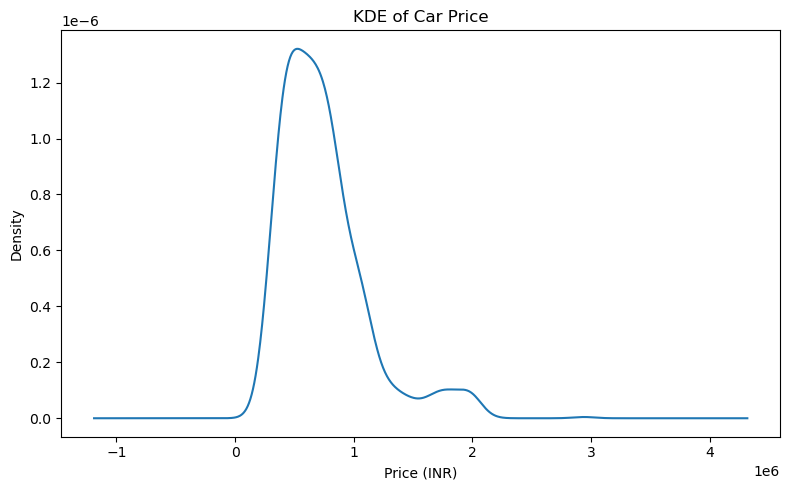


--- Price by Body Type ---
           count        mean        std       min       25%        50%  \
Body_Type                                                                
crossover   21.0   705095.24   72849.78  608000.0  638000.0   706000.0   
hatchback  484.0   533977.27  173086.73  188000.0  401750.0   509000.0   
muv         38.0   626421.05  184093.49  328000.0  489750.0   621500.0   
sedan      227.0   809784.14  286736.77  368000.0  598000.0   772000.0   
suv        206.0  1176495.15  417479.03  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000.0  
suv        1491250.0  2100000.0  


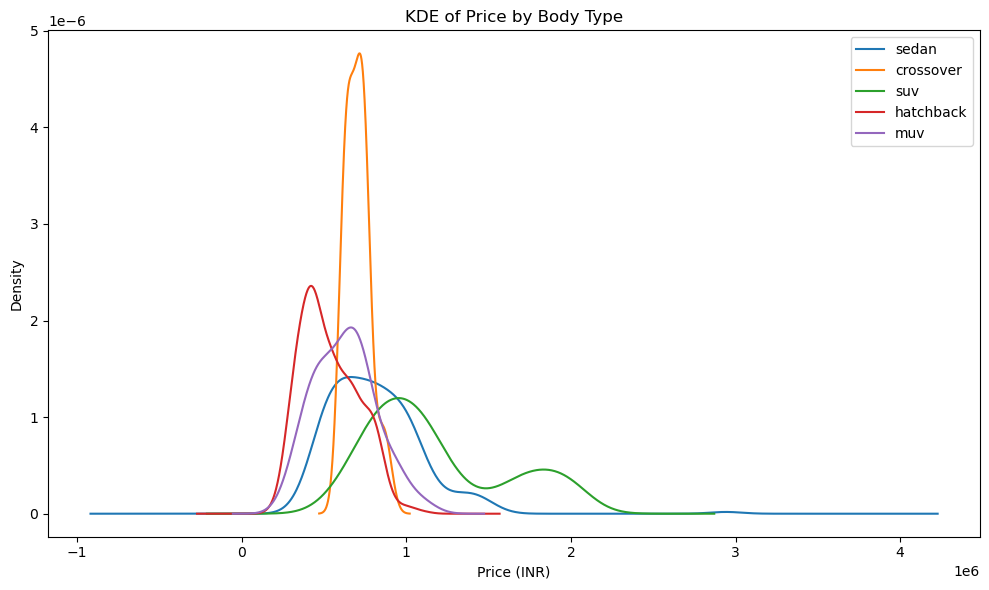

In [ ]:
# Overall KDE
fig, ax = plt.subplots(figsize=(8, 5))
df['Price'].plot.kde(ax=ax)
ax.set_title('KDE of Car Price')
ax.set_xlabel('Price (INR)')
plt.tight_layout()
plt.savefig('price_kde.png', dpi=150)
plt.show()

# Summary by Body Type
print("\n--- Price by Body Type ---")
print(df.groupby('Body_Type')['Price'].describe().round(2))

# Grouped KDE by Body Type
fig, ax = plt.subplots(figsize=(10, 6))
for body in df['Body_Type'].unique():
    subset = df[df['Body_Type'] == body]['Price'].dropna()
    subset.plot.kde(ax=ax, label=body)
ax.set_title('KDE of Price by Body Type')
ax.set_xlabel('Price (INR)')
ax.legend()
plt.tight_layout()
plt.savefig('price_kde_by_bodytype.png', dpi=150)
plt.show()

In [ ]:
# ── Q3.2 — Regress Price on Seating Capacity ──────────────────────────────────
df_clean = df.dropna(subset=['Price', 'Seating_Capacity'])

# Continuous regression
X_cont = sm.add_constant(df_clean['Seating_Capacity'])
model_cont = sm.OLS(df_clean['Price'], X_cont).fit()
print("\n--- Q3.2a: Price ~ Seating_Capacity (continuous) ---")
print(model_cont.summary())
print(f"\nSlope: A one-seat increase is associated with a "
      f"INR {model_cont.params['Seating_Capacity']:,.2f} change in price, holding all else constant.")

# One-hot encoded regression (treat as categorical)
dummies_seat = pd.get_dummies(df_clean['Seating_Capacity'], drop_first=True, dtype=int)
X_cat = sm.add_constant(dummies_seat)
model_cat = sm.OLS(df_clean['Price'], X_cat).fit()
print("\n--- Q3.2b: Price ~ Seating_Capacity (categorical) ---")
print(model_cat.summary())

# Compare group means vs coefficients
group_means = df_clean.groupby('Seating_Capacity')['Price'].mean().sort_index()
diffs = group_means.diff().dropna()
print("\nGroup means by Seating Capacity:")
print(group_means.round(2))
print("\nPrice differences between consecutive seat counts:")
print(diffs.round(2))
cv = diffs.std() / diffs.mean()
if cv < 0.3:
    print("\nThe differences are roughly consistent — the relationship is approximately linear.")
else:
    print("\nThe differences vary quite a bit — the relationship is NOT roughly linear in number of seats.")


--- Q3.2a: Price ~ Seating_Capacity (continuous) ---
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0245
Time:                        03:33:17   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------


--- Q3.3: 10-Fold CV Results by Polynomial Degree ---
   Degree  Mean RMSE  Std RMSE
0       1  310765.36  28322.05
1       2  310779.30  28494.48
2       3  309697.34  28822.90
3       4  308871.57  28694.82
4       5  307368.98  28095.27
5       6  307522.52  28086.58
6       7  306433.42  28063.00
7       8  304974.92  29464.72
8       9  304139.00  29933.57
9      10  304176.87  29994.45

Optimal number of powers of Age: 9


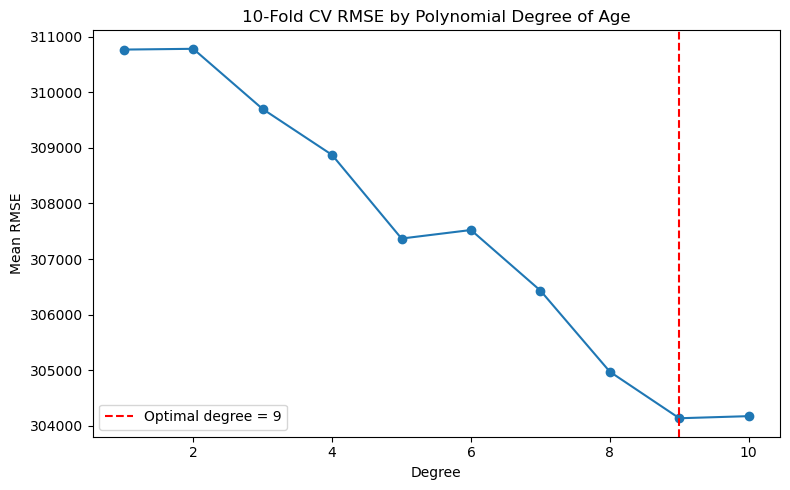

In [ ]:
# ── Q3.3 — Age variable + polynomial cross validation ─────────────────────────
current_year = 2024
df_clean = df.dropna(subset=['Price', 'Make_Year']).copy()
df_clean['Age'] = current_year - df_clean['Make_Year']

def cross_val_rmse_poly(df, max_degree=10, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    y = df['Price'].reset_index(drop=True)

    for degree in range(1, max_degree + 1):
        # Build polynomial features
        X = pd.DataFrame({'const': 1}, index=df.index)
        for d in range(1, degree + 1):
            X[f'Age^{d}'] = df['Age'] ** d
        X = X.reset_index(drop=True)

        rmses = []
        for train_idx, test_idx in kf.split(X):
            X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
            y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
            model = sm.OLS(y_train, X_train).fit()
            preds = model.predict(X_test)
            rmses.append(np.sqrt(mean_squared_error(y_test, preds)))

        results.append({'Degree': degree, 'Mean RMSE': np.mean(rmses), 'Std RMSE': np.std(rmses)})

    return pd.DataFrame(results)

cv_results = cross_val_rmse_poly(df_clean, max_degree=10)
print("\n--- Q3.3: 10-Fold CV Results by Polynomial Degree ---")
print(cv_results.round(2))

best_degree = cv_results.loc[cv_results['Mean RMSE'].idxmin(), 'Degree']
print(f"\nOptimal number of powers of Age: {best_degree}")

# Plot CV results
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cv_results['Degree'], cv_results['Mean RMSE'], marker='o')
ax.axvline(best_degree, color='red', linestyle='--', label=f'Optimal degree = {best_degree}')
ax.set_title('10-Fold CV RMSE by Polynomial Degree of Age')
ax.set_xlabel('Degree')
ax.set_ylabel('Mean RMSE')
ax.legend()
plt.tight_layout()
plt.savefig('cv_rmse_by_degree.png', dpi=150)
plt.show()

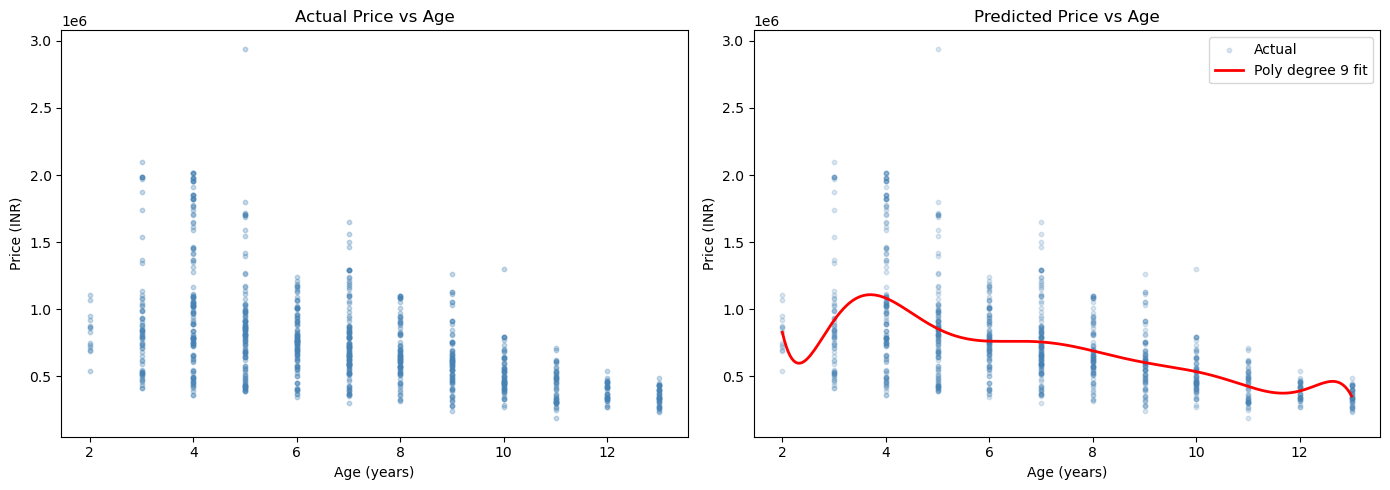


Model R-squared: 0.3137
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.314
Model:                            OLS   Adj. R-squared:                  0.307
Method:                 Least Squares   F-statistic:                     49.06
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           4.17e-73
Time:                        03:33:18   Log-Likelihood:                -13707.
No. Observations:                 976   AIC:                         2.743e+04
Df Residuals:                     966   BIC:                         2.748e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.742e+07   2.3

In [ ]:
# ── Q3.4 — Plot Price vs Age + model predictions ──────────────────────────────

# Fit the best model on full data
X_best = pd.DataFrame({'const': 1}, index=df_clean.index)
for d in range(1, best_degree + 1):
    X_best[f'Age^{d}'] = df_clean['Age'] ** d

model_best = sm.OLS(df_clean['Price'], X_best).fit()
df_clean['Predicted_Price'] = model_best.predict(X_best)

# Create smooth prediction line
age_range = np.linspace(df_clean['Age'].min(), df_clean['Age'].max(), 300)
X_smooth = pd.DataFrame({'const': 1}, index=range(len(age_range)))
for d in range(1, best_degree + 1):
    X_smooth[f'Age^{d}'] = age_range ** d
predicted_smooth = model_best.predict(X_smooth)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual prices vs Age
axes[0].scatter(df_clean['Age'], df_clean['Price'], alpha=0.3, s=10, color='steelblue')
axes[0].set_title('Actual Price vs Age')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Price (INR)')

# Model predicted prices vs Age
axes[1].scatter(df_clean['Age'], df_clean['Price'], alpha=0.2, s=10, color='steelblue', label='Actual')
axes[1].plot(age_range, predicted_smooth, color='red', linewidth=2, label=f'Poly degree {best_degree} fit')
axes[1].set_title('Predicted Price vs Age')
axes[1].set_xlabel('Age (years)')
axes[1].set_ylabel('Price (INR)')
axes[1].legend()

plt.tight_layout()
plt.savefig('price_vs_age.png', dpi=150)
plt.show()

print(f"\nModel R-squared: {model_best.rsquared:.4f}")
print(model_best.summary())

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [ ]:
df = pd.read_csv('scratchpad/data/heart_hw.csv')
df.columns = df.columns.str.strip()
print(df.head())
print(df.dtypes)

   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
Unnamed: 0     int64
age            int64
transplant    object
y              int64
dtype: object


In [ ]:
# ── Q4.1 — Survival proportions + ATE ─────────────────────────────────────────
survival = df.groupby('transplant')['y'].mean()
prop_control   = survival['control']
prop_treatment = survival['treatment']
ate = prop_treatment - prop_control

print("\n--- Q4.1: Survival Proportions ---")
print(f"Control group survival rate:   {prop_control:.4f}")
print(f"Treatment group survival rate: {prop_treatment:.4f}")
print(f"ATE (treatment - control):     {ate:.4f}")


--- Q4.1: Survival Proportions ---
Control group survival rate:   0.1176
Treatment group survival rate: 0.3478
ATE (treatment - control):     0.2302


In [ ]:
# ── Q4.2 — Regress y on transplant ────────────────────────────────────────────
df['treatment_dummy'] = (df['transplant'] == 'treatment').astype(int)

X2 = sm.add_constant(df['treatment_dummy'])
model2 = sm.OLS(df['y'], X2).fit()
print("\n--- Q4.2: y ~ transplant ---")
print(model2.summary())
print(f"\nIntercept = control group survival rate ({prop_control:.4f})")
print(f"Transplant coef = ATE ({ate:.4f})")
print("These match the numbers from Q4.1 exactly.")


--- Q4.2: y ~ transplant ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Wed, 25 Mar 2026   Prob (F-statistic):             0.0133
Time:                        03:33:18   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const       


--- Q4.3: y ~ transplant + age ---
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Wed, 25 Mar 2026   Prob (F-statistic):           0.000357
Time:                        03:33:18   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const 

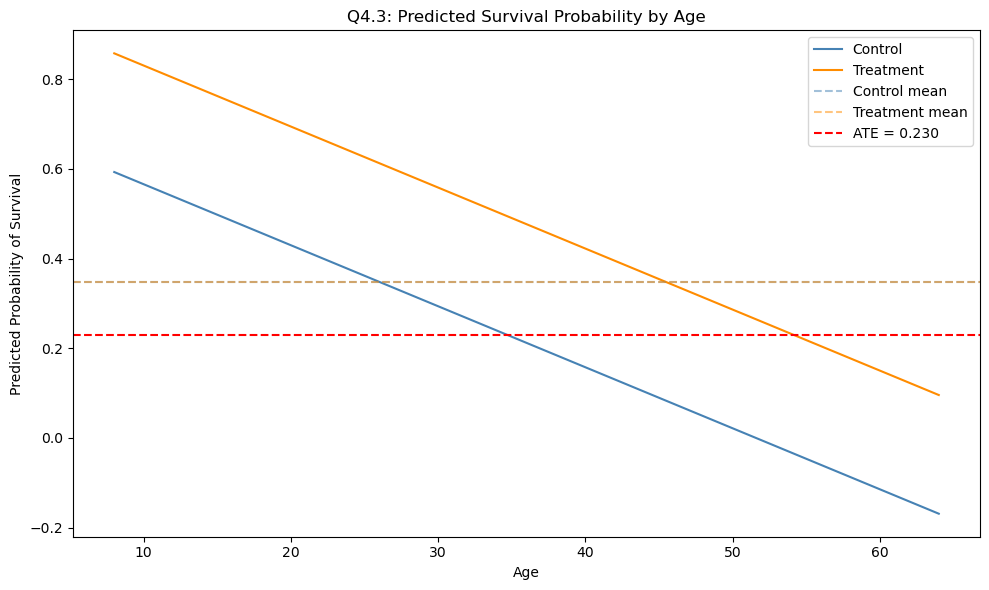

IndexError: index -1 is out of bounds for axis 0 with size 0

In [ ]:
# ── Q4.3 — Regress y on transplant + age ──────────────────────────────────────
df_clean = df.dropna(subset=['y', 'age', 'transplant']).copy()
df_clean['treatment_dummy'] = (df_clean['transplant'] == 'treatment').astype(int)

X3 = sm.add_constant(df_clean[['treatment_dummy', 'age']])
model3 = sm.OLS(df_clean['y'], X3).fit()
print("\n--- Q4.3: y ~ transplant + age ---")
print(model3.summary())
print(f"\nTransplant coef (Q4.2): {model2.params['treatment_dummy']:.4f}")
print(f"Transplant coef (Q4.3): {model3.params['treatment_dummy']:.4f}")
print("\nIntercept: predicted survival probability for a control patient at age 0 (extrapolation)")
print(f"Age slope: each additional year of age changes survival probability by {model3.params['age']:.4f}")

# Plot predicted probability by age
age_range = np.linspace(df_clean['age'].min(), df_clean['age'].max(), 200)

X_control   = pd.DataFrame({'const': 1, 'treatment_dummy': 0, 'age': age_range})
X_treatment = pd.DataFrame({'const': 1, 'treatment_dummy': 1, 'age': age_range})

pred_control   = model3.predict(X_control)
pred_treatment = model3.predict(X_treatment)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(age_range, pred_control,   label='Control',   color='steelblue')
ax.plot(age_range, pred_treatment, label='Treatment',  color='darkorange')
ax.axhline(ate + prop_control, color='steelblue',  linestyle='--', alpha=0.5, label='Control mean')
ax.axhline(prop_treatment,     color='darkorange', linestyle='--', alpha=0.5, label='Treatment mean')
ax.axhline(ate, color='red', linestyle='--', linewidth=1.5, label=f'ATE = {ate:.3f}')
ax.set_title('Q4.3: Predicted Survival Probability by Age')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted Probability of Survival')
ax.legend()
plt.tight_layout()
plt.savefig('q4_3_predictions.png', dpi=150)
plt.show()

gap = pred_treatment - pred_control
over_idx  = np.where(gap > ate)[0]
under_idx = np.where(gap < ate)[0]
if len(over_idx):
    print(f"\nATE overestimates transplant impact for ages above ~{age_range[under_idx[-1]]:.0f}")
    print(f"ATE underestimates transplant impact for ages below ~{age_range[under_idx[-1]]:.0f}")

In [ ]:
# ── Q4.4 — Add transplant * age interaction ────────────────────────────────────
df_clean['interaction'] = df_clean['treatment_dummy'] * df_clean['age']

X4 = sm.add_constant(df_clean[['treatment_dummy', 'age', 'interaction']])
model4 = sm.OLS(df_clean['y'], X4).fit()
print("\n--- Q4.4: y ~ transplant + age + transplant*age ---")
print(model4.summary())

# Predicted values with interaction
X_control_int   = pd.DataFrame({
    'const': 1, 'treatment_dummy': 0,
    'age': age_range, 'interaction': 0
})
X_treatment_int = pd.DataFrame({
    'const': 1, 'treatment_dummy': 1,
    'age': age_range, 'interaction': age_range
})

pred_control_int   = model4.predict(X_control_int)
pred_treatment_int = model4.predict(X_treatment_int)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(age_range, pred_control_int,   label='Control',  color='steelblue')
ax.plot(age_range, pred_treatment_int, label='Treatment', color='darkorange')
ax.axhline(ate, color='red', linestyle='--', linewidth=1.5, label=f'ATE = {ate:.3f}')
ax.set_title('Q4.4: Predicted Survival Probability by Age (with Interaction)')
ax.set_xlabel('Age')
ax.set_ylabel('Predicted Probability of Survival')
ax.legend()
plt.tight_layout()
plt.savefig('q4_4_predictions.png', dpi=150)
plt.show()

gap_int = pred_treatment_int - pred_control_int
print(f"\nInteraction term: {model4.params['interaction']:.4f}")
print("A negative interaction term means the transplant benefit shrinks (or reverses) with age.")
print("A positive interaction term means the transplant benefit grows with age.")

In [ ]:
# ── Q4.5 — 10-Fold Cross Validation ───────────────────────────────────────────
from sklearn.metrics import accuracy_score
def cross_val_metrics(X, y, n_splits=10):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    rmses, accs = [], []
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        model = sm.OLS(y_train, X_train).fit()
        preds = model.predict(X_test)
        rmses.append(np.sqrt(mean_squared_error(y_test, preds)))
        preds_binary = (preds >= 0.5).astype(int)
        accs.append(accuracy_score(y_test, preds_binary))
    return np.mean(rmses), np.mean(accs)

y_cv = df_clean['y']
X2_cv = sm.add_constant(df_clean['treatment_dummy'])
X3_cv = sm.add_constant(df_clean[['treatment_dummy', 'age']])
X4_cv = sm.add_constant(df_clean[['treatment_dummy', 'age', 'interaction']])

rmse2, acc2 = cross_val_metrics(X2_cv, y_cv)
rmse3, acc3 = cross_val_metrics(X3_cv, y_cv)
rmse4, acc4 = cross_val_metrics(X4_cv, y_cv)

print("\n--- Q4.5: 10-Fold Cross Validation ---")
print(f"{'Model':<35} {'RMSE':>8} {'Accuracy':>10}")
print(f"{'Model 2 (transplant only)':<35} {rmse2:>8.4f} {acc2:>10.4f}")
print(f"{'Model 3 (transplant + age)':<35} {rmse3:>8.4f} {acc3:>10.4f}")
print(f"{'Model 4 (+ interaction)':<35} {rmse4:>8.4f} {acc4:>10.4f}")

In [ ]:
# ── Q4.6 — Ethical concerns ───────────────────────────────────────────────────
print("""
--- Q4.6: Concerns about Model Construction and Deployment ---

1. LINEAR PROBABILITY MODEL: Predicting a binary outcome with OLS can produce
   probabilities outside [0,1], making predictions nonsensical for some patients.
   Logistic regression would be more appropriate.

2. OMITTED VARIABLE BIAS: The model only controls for age. Many other factors
   (severity of illness, comorbidities, socioeconomic status) are excluded,
   meaning the transplant coefficient may be biased.

3. SELECTION BIAS: Patients who receive transplants are not randomly assigned.
   Doctors likely give transplants to patients most likely to benefit, which
   confounds the estimated treatment effect.

4. AGE DISCRIMINATION: If the model shows weaker transplant benefits for older
   patients, using it to allocate transplants could systematically deprioritize
   elderly patients, raising serious ethical and legal concerns.

5. SMALL/UNREPRESENTATIVE SAMPLE: If the dataset is small or unrepresentative,
   the model may not generalize to broader populations, leading to unfair or
   inaccurate prioritization decisions.

6. FEEDBACK LOOPS: Deploying the model to allocate transplants changes who gets
   treated, which changes future survival data, which could reinforce existing
   biases in the model over time.
""")